In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

Data Ingestion

In [ ]:
file_path = os.path.join('..', 'data', 'patients.csv')

    # Load the dataset
patients_data = pd.read_csv(file_path)
    
print(patients_data.head())
print(patients_data.info())

     patient_id               name  age arrival_date departure_date  \
0  PAT-09484753  Richard Rodriguez   24   2025-03-16     2025-03-22   
1  PAT-f0644084     Shannon Walker    6   2025-12-13     2025-12-14   
2  PAT-ac6162e4       Julia Torres   24   2025-06-29     2025-07-05   
3  PAT-3dda2bb5    Crystal Johnson   32   2025-10-12     2025-10-23   
4  PAT-08591375        Garrett Lin   25   2025-02-18     2025-02-25   

            service  satisfaction  
0           surgery            61  
1           surgery            83  
2  general_medicine            83  
3         emergency            81  
4               ICU            76  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   patient_id      1000 non-null   object
 1   name            1000 non-null   object
 2   age             1000 non-null   int64 
 3   arrival_date    1000 non-nu

In [14]:
services_file_path = os.path.join('..', 'data', 'services_weekly.csv')

    # Load the dataset
services_weekly_data = pd.read_csv(services_file_path)
    
print(services_weekly_data.head())
print(services_weekly_data.info())

   week  month           service  available_beds  patients_request  \
0     1      1         emergency              32                76   
1     1      1           surgery              45               130   
2     1      1  general_medicine              37               201   
3     1      1               ICU              22                31   
4     2      1         emergency              28               169   

   patients_admitted  patients_refused  patient_satisfaction  staff_morale  \
0                 32                44                    67            70   
1                 45                85                    83            78   
2                 37               164                    97            43   
3                 22                 9                    84            91   
4                 28               141                    75            64   

  event  
0  none  
1   flu  
2   flu  
3   flu  
4  none  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 

In [16]:
schedule_file_path = os.path.join('..', 'data', 'staff_schedule.csv')

    # Load the dataset
staff_schedule_data = pd.read_csv(schedule_file_path)
    
print(staff_schedule_data.head())
print(staff_schedule_data.info())

   week      staff_id    staff_name    role    service  present
0     1  STF-b77cdc60  Allison Hill  doctor  emergency        1
1     2  STF-b77cdc60  Allison Hill  doctor  emergency        1
2     3  STF-b77cdc60  Allison Hill  doctor  emergency        0
3     4  STF-b77cdc60  Allison Hill  doctor  emergency        1
4     5  STF-b77cdc60  Allison Hill  doctor  emergency        1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6552 entries, 0 to 6551
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   week        6552 non-null   int64 
 1   staff_id    6552 non-null   object
 2   staff_name  6552 non-null   object
 3   role        6552 non-null   object
 4   service     6552 non-null   object
 5   present     6552 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 307.2+ KB
None


In [17]:
staff_file_path = os.path.join('..', 'data', 'staff.csv')

    # Load the dataset
staff_data = pd.read_csv(staff_file_path)
    
print(staff_data.head())
print(staff_data.info())

       staff_id       staff_name    role    service
0  STF-5ca26577     Allison Hill  doctor  emergency
1  STF-02ae59ca      Noah Rhodes  doctor  emergency
2  STF-d8006e7c  Angie Henderson  doctor  emergency
3  STF-212d8b31    Daniel Wagner  doctor  emergency
4  STF-107a58e4  Cristian Santos  doctor  emergency
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   staff_id    110 non-null    object
 1   staff_name  110 non-null    object
 2   role        110 non-null    object
 3   service     110 non-null    object
dtypes: object(4)
memory usage: 3.6+ KB
None


Data Exploration

Data Transformation

In [20]:
#  Convert Patient dates
patients_data['arrival_date'] = pd.to_datetime(patients_data['arrival_date'])
patients_data['departure_date'] = pd.to_datetime(patients_data['departure_date'])

Text(0.5, 1.0, 'Distribution of Length of Stay')

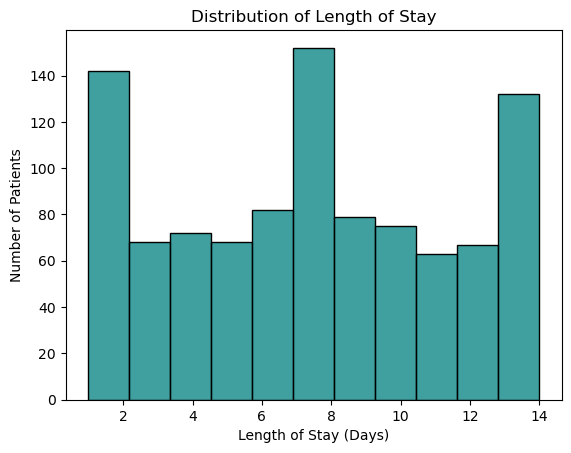

In [29]:
# Calculate Length of stay
patients_data['length of stay'] = (patients_data['departure_date'] - patients_data['arrival_date']).dt.days
sns.histplot(patients_data['length of stay'], color='teal')
plt.xlabel('Length of Stay (Days)')
plt.ylabel('Number of Patients')
plt.title('Distribution of Length of Stay')

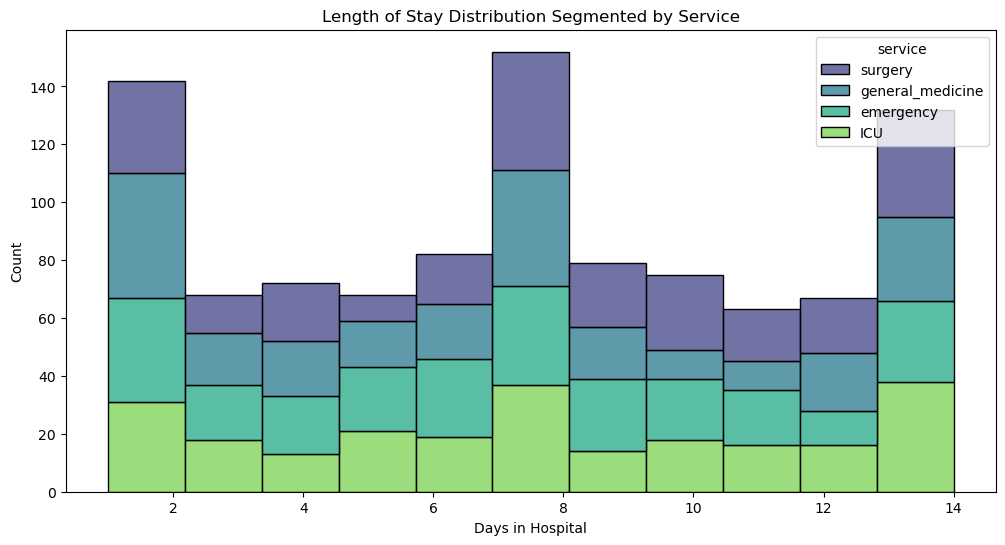

In [34]:
plt.figure(figsize=(12, 6))
sns.histplot(data = patients_data, x=patients_data['length of stay'], hue='service', multiple='stack', palette='viridis')
plt.title('Length of Stay Distribution Segmented by Service')
plt.xlabel('Days in Hospital')
plt.show()

In [21]:
# Aggregate Staffing to Weekly Level
# To know how many staff members were actually present per week per service
weekly_staff_stats = staff_schedule_data.groupby(['week', 'service'])['present'].sum().reset_index()
weekly_staff_stats.rename(columns={'present': 'staff_on_duty'}, inplace=True)

In [22]:
#Merg Staff schedules and weekly performances
master_df = pd.merge(services_weekly_data, weekly_staff_stats, on=['week', 'service'], how='left')